### 神经网络
人工神经网络(Artificial Neural Network, ANN) 也称之为神经网络，是一种模仿生物神经网络结构和功能的**计算模型**。
特点：
1. 同一层的神经元之间没有连接
2. 第 N 层的每个神经元和第 N-1 层的所有神经元相连（这就是full connected的含义），这就是全连接神经网络
3. 全连接神经网络接受的样本数据是二维的，数据在每一层之间需要以二维的形式传递
4. 第 N-1 层神经元的输出就是第 N 层神经元的输入
5. 每个连接都有一个权重值（w系数和b系数）

每一个神经元工作时，前向传播会产生两个值，内部状态值（加权求和值）和激活值；反向传播时会产生激活值梯度和内部状态值梯度
内部状态值：神经元或隐藏单元的内部存储值，它反映了当前神经元接受到的输入、历史信息以及网络内部的权重计算结果。 z = Wx + b
激活值：通过激活函数（ReLu，Sigmoid，Tanh）对内部状态值进行非线性变换后得到的结果。 a = f(z)

### 激活函数
激活函数用于对每层的输出数据进行变换，进而为整个网络注入了非线性因素。此时，神经网络就可以拟合各种曲线。
1. 没有引入非线性因素的网络等价于使用一个线性模型来拟合
2. 通过给网络输出增加激活函数，实现引入非线性因素，使得网络模型可以逼近任意函数，提升网络对复杂问题的拟合能力。

#### sigmoid激活函数
激活函数公式：$ f(x)=\frac{1}{1+e^{-x}} $
激活函数求导公式：$ f'(x)=(\frac{1}{1+e^{-x}})'=\frac{1}{1+e^{-x}}(1-\frac{1}{1+e^{-x}})=f(x)(1-f(x)) $

sigmoid函数可以将任意的输入映射到 (0,1) 之间，当输入的值大致在<-6 或者 >6时，意味着输入任何值所得到的激活值都是差不多的，这样会丢失部分的信息。比如：输入100 和 输入 10000 经过sigmoid的激活值几乎都是等于1的，但是输入的数据之间相差100倍的信息就丢失了。
对于sigmoid函数而言，输入值在 [-6, 6] 之间输出值才有明显差异，输入值在 [-3, 3] 之间才会有比较好的效果
通过导数图像，可以发现导数数值范围在 (0, 0.25)，当输入 < -6 或者 > 6 时，sigmoid激活函数图像的导数接近为0，此时网络参数将更新及其缓慢，或者无法更新
一般开始，sigmoid 网络在 5 层之内就会产生梯度消失现象。而且，该激活函数并不是以 0 为中心的，所以在实践中这种激活函数使用的很少。**sigmoid函数一般只用于二分类的输出层**。

Text(0.5, 1.0, 'Sigmoid 激活函数的导数图像')

D:\Program Files\Anaconda\anaconda3\envs\pytorch\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 20989 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Program Files\Anaconda\anaconda3\envs\pytorch\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 25968 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Program Files\Anaconda\anaconda3\envs\pytorch\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 22270 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Program Files\Anaconda\anaconda3\envs\pytorch\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 20687 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Program Files\Anaconda\anaconda3\envs\pytorch\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 28608 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Pr

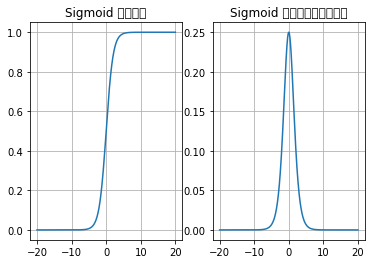

In [21]:
import torch
import matplotlib.pyplot as plt

# 创建画布和坐标轴
_, axes = plt.subplots(1, 2)
# 函数图像
x = torch.linspace(-20, 20, 1000)
y = torch.sigmoid(x)
axes[0].plot(x, y)
axes[0].grid()
axes[0].set_title("Sigmoid 函数图像")

x = torch.linspace(-20, 20, 1000, requires_grad=True)
torch.sigmoid(x).sum().backward()
axes[1].plot(x.detach(), x.grad)
axes[1].grid()
axes[1].set_title("Sigmoid 激活函数的导数图像")

#### Tanh 激活函数
Tanh公式：$ f(x) = \frac{1-e^{-2x}}{1+e^{-2x}} $
激活函数求导公式：$ f'(x) = (\frac{1-e^{-2x}}{1+e^{-2x}})' = 1 - f^2(x) $

1. Tanh函数将输入映射到(-1, 1)之间，图像以0为中心，在0点对称，当输入 <-3 或 >3 时将被映射为-1或1。其导数值范围(0,1)，当输入的值大概<-3 或 >3时，其导数近似为0.
2. 与Sigmoid相比，它是**以0为中心的**,且梯度相对于Sigmoid大，使得其收敛速度要比Sigmoid快，减少迭代次数。然而，从图中可以看出，Tanh两侧的导数也为0，同样会造成梯度消失。
3. 若使用时可在隐藏层使用tanh函数，在输出层使用sigmoid函数。

D:\Program Files\Anaconda\anaconda3\envs\pytorch\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 20989 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Program Files\Anaconda\anaconda3\envs\pytorch\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 25968 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Program Files\Anaconda\anaconda3\envs\pytorch\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 22270 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Program Files\Anaconda\anaconda3\envs\pytorch\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 20687 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Program Files\Anaconda\anaconda3\envs\pytorch\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 23548 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Pr

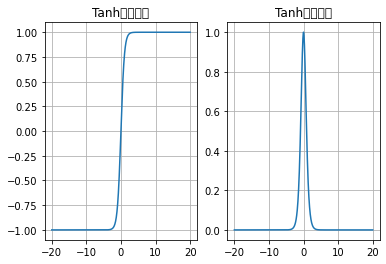

In [19]:
import torch
import matplotlib.pyplot as plt

_, axes = plt.subplots(1, 2)
x = torch.linspace(-20, 20, 1000)
y = torch.tanh(x)

axes[0].plot(x, y)
axes[0].grid()
axes[0].set_title("Tanh函数图像")

x = torch.linspace(-20, 20, 1000, requires_grad=True)
torch.tanh(x).sum().backward()
axes[1].plot(x.detach(), x.grad)
axes[1].grid()
axes[1].set_title("Tanh导数图像")
plt.show()

#### ReLU激活函数
ReLU公式：$ f(x) = max(0,x) $
激活函数求导公式：$ f'(x)=0或1 $
ReLU只考虑正样本
1. ReLu激活函数将小于0的值映射为0，而大于0的值则保持不变，它更加重视正信号，而忽略负信号，这种激活函数运算更为简单，能够提升模型的训练效率
2. 当x<0时，ReLu导数为0，当x>0时，则不存在饱和问题。所以，ReLU能够在x>0时保持梯度不衰减，从而缓解梯度消失问题。然而，随着训练的推进，部分输入会落到小于0区域，导致对应权重无法更新。这种现象叫做“神经元死亡”。
3. ReLU是目前最常用的激活函数。与Sigmoid函数相比，ReLU的优势：采用Sigmoid函数，计算量大(指数函数运算)，反向传播求误差梯度时，计算量相对大，而采用Relu激活函数，整个过程的计算量减少很多。Sigmoid函数反向传播时，很容易就会出现梯度消失的情况，从而无法完成深层网络的训练。Relu会使一部分神经元输出为0，这样就造成了网络的稀疏性，并且减少了参数的相互依存关系，缓解了过拟合的问题。

#### Leaky ReLU
$$ f(x) = \begin{cases} 0.01x && x<0 \\ x && x \ge 0 \end{cases} $$
$$ f'(x) = \begin{cases} 0.01 && x<0 \\ 1 && x \ge 0 \end{cases} $$

#### PReLU
$$ f(\alpha, x) = \begin{cases} \alpha x && x<0 \\ x && x \ge 0 \end{cases} $$
$$ f'(\alpha, x) = \begin{cases} \alpha && x<0 \\ 1 && x \ge 0 \end{cases} $$

#### RReLU
$$ f(\alpha, x) = \begin{cases} \alpha x && x<0 \\ x && x \ge 0 \end{cases} $$
$$ f'(\alpha, x) = \begin{cases} \alpha && x<0 \\ 1 && x \ge 0 \end{cases} $$

#### ELU
$$ f(\alpha, x) = \begin{cases} \alpha(e^x-1) && x<0 \\ x && x \ge 0 \end{cases} $$
$$ f'(\alpha, x) = \begin{cases} f(\alpha,x)+\alpha && x<0 \\ 1 && x \ge 0 \end{cases} $$

Text(0.5, 1.0, 'ReLU导数图像')

D:\Program Files\Anaconda\anaconda3\envs\pytorch\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 20989 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Program Files\Anaconda\anaconda3\envs\pytorch\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 25968 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Program Files\Anaconda\anaconda3\envs\pytorch\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 22270 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Program Files\Anaconda\anaconda3\envs\pytorch\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 20687 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Program Files\Anaconda\anaconda3\envs\pytorch\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 23548 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Pr

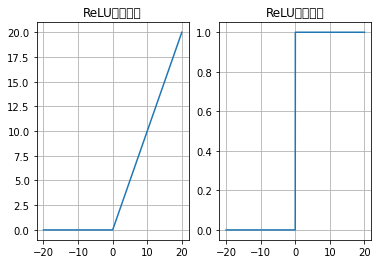

In [23]:
import torch
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2)
x = torch.linspace(-20, 20, 1000)
y = torch.relu(x)
axes[0].plot(x, y)
axes[0].grid()
axes[0].set_title("ReLU函数图像")

x = torch.linspace(-20, 20, 1000, requires_grad=True)
torch.relu(x).sum().backward()
axes[1].plot(x.detach(), x.grad)
axes[1].grid()
axes[1].set_title("ReLU导数图像")

#### Softmax激活函数
softmax用于多分类过程，它是二分类函数sigmoid在多分类上的推广，目的是将多分类的结果以概率的形式展现出来。
公式：$ softmax(z_i)=\frac{e^{z_i}}{\sum_j{e^{z_j}}} $
softmax就是将网络输出的logits通过softmax函数，映射成（0，1）的值，而这些值的累和为1，那么可以将他理解为概率，选取概率最大节点，作为预测目标类别

In [25]:
import torch

x = torch.tensor([0.2, 0.02, 0.23, 0.56, 0.23, 1.5, 1.1, 0.05, 3.75, 3.1])
probabilities = torch.softmax(x, dim=0)
print(probabilities)
x = torch.tensor([[0.2, 0.3, 0.34, 0.23], [0.32, 0.45, 0.23, 0.56]])
probabilities = torch.softmax(x, dim=1)
print(probabilities)

tensor([0.0153, 0.0128, 0.0158, 0.0219, 0.0158, 0.0562, 0.0377, 0.0132, 0.5331,
        0.2783])
tensor([[0.2333, 0.2579, 0.2684, 0.2404],
        [0.2313, 0.2634, 0.2114, 0.2940]])


### 激活函数选择方法
对于隐藏层
1. 优先选择ReLU激活函数
2. 如果ReLU效果不好，那么尝试其他激活函数，如Leaky ReLU等。
3. 如果使用了ReLU，需要注意Dead ReLU问题，避免出现0梯度从而导致过多的神经元死亡
4. 少使用sigmoid函数，可以尝试使用tanh激活函数

对于输出层
1. 二分类问题选择sigmoid函数
2. 多分类问题选择softmax函数
3. 回归问题选择identity函数